# EDA — KPIs de Aftersales | Rede de Concessionárias

**Projeto de Portfólio | Análise de Pós-Venda**

---

## Objetivo

Analisar dados de uma rede de concessionárias brasileira cobrindo os principais
KPIs de Aftersales exigidos no setor automotivo:

- Sell-in vs Sell-out de peças
- Retenção e Churn de clientes
- Segmentação por canal de distribuição
- Análise de margem e ticket médio
- CSAT e qualidade de atendimento
- Funil de pós-venda e recompra

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Paleta de cores 
CORES = {
    'primaria'  : "#1310C8",  # azul vibrante 
    'secundaria': '#1A1A2E',  # azul escuro
    'acento'    : '#F5A623',  # âmbar
    'verde'     : '#27AE60',
    'cinza'     : '#BDC3C7',
    'fundo'     : '#F7F9FC',
    'texto'     : '#2C3E50',
}

PALETA = [
    CORES['primaria'], CORES['secundaria'], CORES['acento'],
    CORES['verde'], '#8E44AD', '#2980B9', '#E67E22', '#16A085'
]

# Estilo global dos gráficos 
plt.rcParams.update({
    'figure.facecolor' : CORES['fundo'],
    'axes.facecolor'   : CORES['fundo'],
    'axes.edgecolor'   : CORES['cinza'],
    'axes.labelcolor'  : CORES['texto'],
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 10,
    'xtick.color'      : CORES['texto'],
    'ytick.color'      : CORES['texto'],
    'font.family'      : 'DejaVu Sans',
    'grid.color'       : CORES['cinza'],
    'grid.alpha'       : 0.4,
})

print('✅ Setup concluído')

✅ Setup concluído


---
## 1. Carregamento e Enriquecimento dos Dados

Carregamos as 7 tabelas do modelo dimensional e fazemos os **joins**
para montar uma tabela analítica enriquecida.


In [140]:
DATA_DIR = "C:\\Users\\fabio\\analytics\\project\\projeto_2_dashboard_pos_venda\\raw"  # pasta onde estão os CSVs
OUTPUT_DIR = r"C:\Users\fabio\analytics\project\projeto_2_dashboard_pos_venda\output"


#  Carregar todas as tabelas 
fa  = pd.read_csv(f'{DATA_DIR}/fato_atendimento.csv',   encoding='utf-8-sig')
fr  = pd.read_csv(f'{DATA_DIR}/fato_recompra.csv',      encoding='utf-8-sig')
dt  = pd.read_csv(f'{DATA_DIR}/dim_tempo.csv',          encoding='utf-8-sig')
dc  = pd.read_csv(f'{DATA_DIR}/dim_concessionaria.csv', encoding='utf-8-sig')
dv  = pd.read_csv(f'{DATA_DIR}/dim_veiculo.csv',        encoding='utf-8-sig')
ds  = pd.read_csv(f'{DATA_DIR}/dim_servico.csv',        encoding='utf-8-sig')
dcl = pd.read_csv(f'{DATA_DIR}/dim_cliente.csv',        encoding='utf-8-sig')

dt['data'] = pd.to_datetime(dt['data'])

# Join principal: fato_atendimento + todas as dimensões 
fa = (
    fa
    .merge(dt[['sk_tempo','data','ano','mes_num','mes_nome','trimestre']], on='sk_tempo')
    .merge(dc[['sk_concessionaria','regiao','uf','canal','porte']], on='sk_concessionaria')
    .merge(ds[['sk_servico','nome_servico','categoria_servico','complexidade']], on='sk_servico')
    .merge(dv[['sk_veiculo','modelo','segmento','combustivel','faixa_preco']], on='sk_veiculo')
    .merge(dcl[['sk_cliente','segmento_cliente','canal_aquisicao','faixa_etaria']], on='sk_cliente')
)

# Filtrar apenas OS concluídas para as análises de receita 
fa_ok = fa[fa['status_os'] == 'Concluída'].copy()

print(f'Total de OS carregadas : {len(fa):,}')
print(f'OS concluídas          : {len(fa_ok):,}')
print(f'Colunas disponíveis    : {fa_ok.shape[1]}')
print(f'\nPrimeiras linhas:')
fa_ok.head()

Total de OS carregadas : 28,000
OS concluídas          : 25,722
Colunas disponíveis    : 35

Primeiras linhas:


,sk_os,id_os,sk_tempo,sk_concessionaria,sk_veiculo,sk_servico,sk_cliente,vlr_mao_obra,vlr_pecas_sellout,vlr_pecas_sellin,...,nome_servico,categoria_servico,complexidade,modelo,segmento,combustivel,faixa_preco,segmento_cliente,canal_aquisicao,faixa_etaria
0,1,OS000001,371,3,75,4,2849,520.82,553.90,362.89,...,Troca de Freios,Manutenção Corretiva,Médio,Cruze,Sedan,Flex,Médio,PF - Varejo,Showroom,46-55
1,2,OS000002,513,3,25,3,964,137.74,132.73,74.04,...,Alinhamento/Balanceamento,Manutenção Preventiva,Baixo,Equinox,SUV,Flex,Premium,PJ - Frota Pequena,Recall,36-45
2,3,OS000003,549,11,75,3,2889,157.31,186.91,129.98,...,Alinhamento/Balanceamento,Manutenção Preventiva,Baixo,Cruze,Sedan,Flex,Médio,PJ - Frota Grande,Showroom,26-35
3,4,OS000004,190,9,41,6,1641,1826.34,1393.00,963.68,...,Reparo de Motor,Manutenção Corretiva,Alto,S10,Pick-up,Flex,Médio,PF - Varejo,Digital,26-35
4,5,OS000005,648,19,55,11,2618,224.04,127.17,75.72,...,Diagnóstico Eletrônico,Diagnóstico,Médio,Spin,Minivan,Flex,Entrada,PF - Varejo,Recall,36-45


---
## 2. Primeiro Olhar nos Dados

Antes de qualquer gráfico, inspecionamos a estrutura e a qualidade dos dados.
Essa etapa responde três perguntas básicas:

- Os tipos de dados estão corretos?
- Existe algum valor nulo que precise de tratamento?
- As métricas numéricas fazem sentido (escala, mínimo, máximo)?

In [141]:
print('=' * 55)
print('  ESTRUTURA DA TABELA ANALÍTICA (fato + dimensões)')
print('=' * 55)
fa_ok.info()

  ESTRUTURA DA TABELA ANALÍTICA (fato + dimensões)
<class 'pandas.DataFrame'>
Index: 25722 entries, 0 to 27999
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   sk_os                25722 non-null  int64         
 1   id_os                25722 non-null  str           
 2   sk_tempo             25722 non-null  int64         
 3   sk_concessionaria    25722 non-null  int64         
 4   sk_veiculo           25722 non-null  int64         
 5   sk_servico           25722 non-null  int64         
 6   sk_cliente           25722 non-null  int64         
 7   vlr_mao_obra         25722 non-null  float64       
 8   vlr_pecas_sellout    25722 non-null  float64       
 9   vlr_pecas_sellin     25722 non-null  float64       
 10  vlr_total_os         25722 non-null  float64       
 11  margem_bruta_pecas   25722 non-null  float64       
 12  tempo_atendimento_h  25722 non-null  int64         
 

In [142]:
print('=' * 55)
print('  VALORES NULOS POR COLUNA')
print('=' * 55)

nulos = fa_ok.isnull().sum()
nulos = nulos[nulos > 0]

if len(nulos) == 0:
    print('Nenhum valor nulo encontrado.')
else:
    print(nulos)

  VALORES NULOS POR COLUNA
Nenhum valor nulo encontrado.


In [143]:
print('=' * 55)
print('  ESTATÍSTICAS DESCRITIVAS — MÉTRICAS FINANCEIRAS')
print('=' * 55)

colunas_metricas = [
    'vlr_mao_obra',
    'vlr_pecas_sellout',
    'vlr_pecas_sellin',
    'vlr_total_os',
    'margem_bruta_pecas',
    'tempo_atendimento_h',
    'csat',
]

fa_ok[colunas_metricas].describe().round(2)

  ESTATÍSTICAS DESCRITIVAS — MÉTRICAS FINANCEIRAS


,vlr_mao_obra,vlr_pecas_sellout,vlr_pecas_sellin,vlr_total_os,margem_bruta_pecas,tempo_atendimento_h,csat
count,25722.00,25722.00,25722.00,25722.00,25722.00,25722.00,25722.00
mean,686.60,549.67,348.59,1236.26,201.08,4.49,4.21
std,807.65,686.29,436.56,1469.13,255.54,2.30,1.01
min,0.00,0.00,0.00,0.00,0.00,1.00,1.00
25%,205.29,152.00,96.12,361.30,54.52,2.00,4.00
50%,396.76,307.82,195.10,716.28,110.68,4.00,5.00
75%,761.56,617.61,392.10,1367.24,226.63,7.00,5.00
max,3998.81,4682.11,3189.91,8625.63,1920.44,8.00,5.00


---
## 3. Sumário Executivo — KPIs Globais



Aqui calculamos os 6 KPIs principais que vão aparecer no dashboard do Power BI:

| KPI | O que mede |
|---|---|
| Receita Total | Volume financeiro gerado pela rede no período |
| Margem Bruta de Peças | Quanto sobra após o custo de aquisição das peças |
| Ticket Médio por OS | Valor médio de cada ordem de serviço |
| CSAT Médio | Satisfação média dos clientes atendidos |
| Taxa de Retorno em 30d | Proxy de retrabalho — cliente voltou com o mesmo problema |

In [144]:
# ── Cálculo dos KPIs globais ─────────────────────────────────────────
receita_total  = fa_ok['vlr_total_os'].sum()
margem_total   = fa_ok['margem_bruta_pecas'].sum()
margem_pct     = margem_total / fa_ok['vlr_pecas_sellout'].sum() * 100
ticket_medio   = fa_ok['vlr_total_os'].mean()
csat_medio     = fa_ok['csat'].mean()
taxa_retorno   = fa_ok['retornou_30d'].mean() * 100
taxa_recompra  = len(fr) / dcl['sk_cliente'].nunique() * 100

print('=' * 50)
print('  KPIs GLOBAIS — JAN/2023 A DEZ/2024')
print('=' * 50)
print(f'  Receita Total       : R$ {receita_total:>12,.2f}')
print(f'  Margem Bruta Peças  : R$ {margem_total:>12,.2f}  ({margem_pct:.1f}%)')
print(f'  Ticket Médio / OS   : R$ {ticket_medio:>12,.2f}')
print(f'  CSAT Médio          :       {csat_medio:.2f} / 5.0')
print(f'  Retorno em 30 dias  :       {taxa_retorno:.1f}%')
print(f'  Taxa de Recompra    :       {taxa_recompra:.1f}%')
print('=' * 50)

  KPIs GLOBAIS — JAN/2023 A DEZ/2024
  Receita Total       : R$ 31,799,151.35
  Margem Bruta Peças  : R$ 5,172,075.02  (36.6%)
  Ticket Médio / OS   : R$     1,236.26
  CSAT Médio          :       4.21 / 5.0
  Retorno em 30 dias  :       7.7%
  Taxa de Recompra    :       17.9%


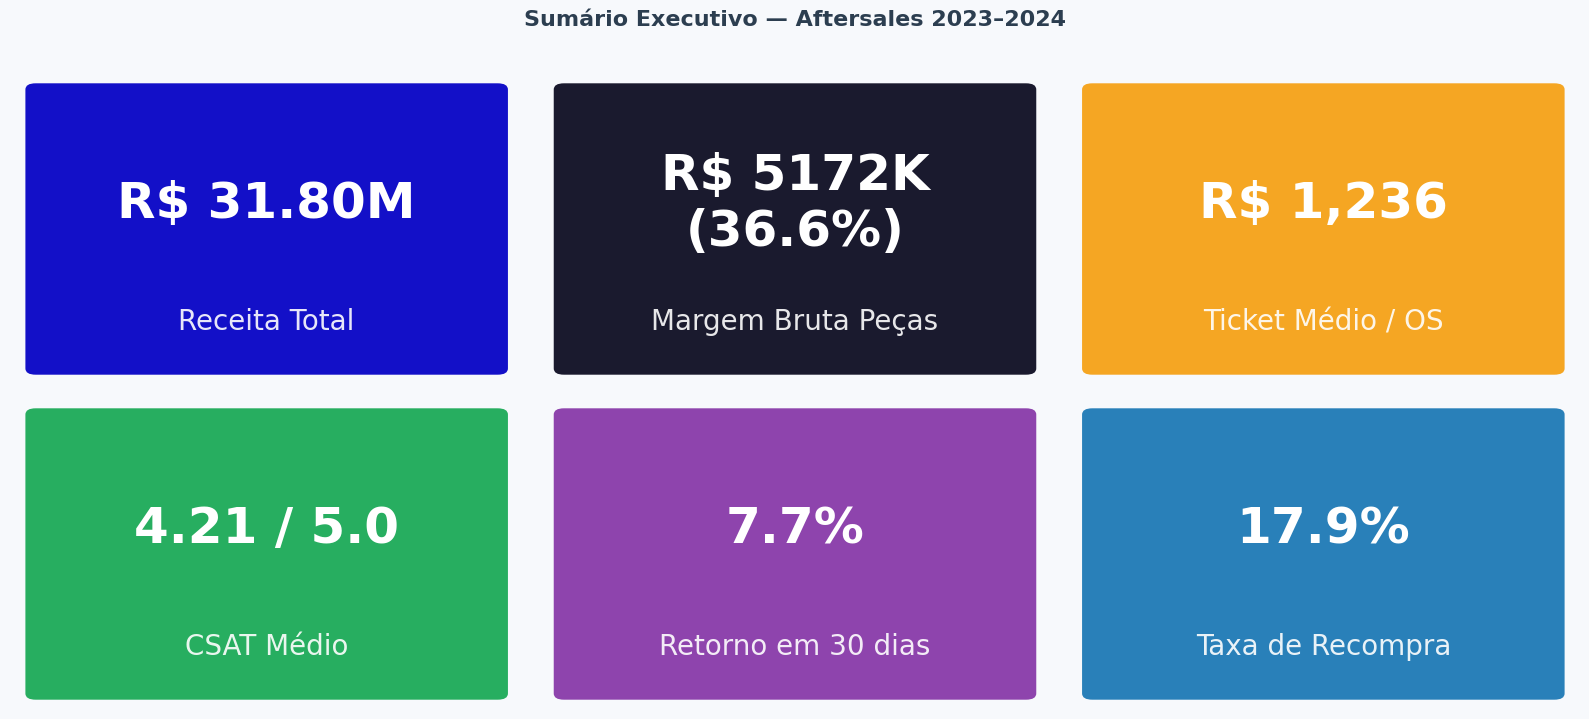

In [145]:
from matplotlib.patches import FancyBboxPatch

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
fig.suptitle('Sumário Executivo — Aftersales 2023–2024',
             fontsize=16, fontweight='bold', color=CORES['texto'], y=1.02)

kpis = [
    ('Receita Total',        f"R$ {receita_total/1_000_000:.2f}M", CORES['primaria']),
    ('Margem Bruta Peças',   f"R$ {margem_total/1_000:.0f}K\n({margem_pct:.1f}%)", CORES['secundaria']),
    ('Ticket Médio / OS',    f"R$ {ticket_medio:,.0f}",            CORES['acento']),
    ('CSAT Médio',           f"{csat_medio:.2f} / 5.0",            CORES['verde']),
    ('Retorno em 30 dias',   f"{taxa_retorno:.1f}%",               '#8E44AD'),
    ('Taxa de Recompra',     f"{taxa_recompra:.1f}%",              '#2980B9'),
]

for ax, (titulo, valor, cor) in zip(axes.flat, kpis):
    # Fundo colorido desenhado como retângulo explícito
    ax.add_patch(FancyBboxPatch(
        (0.05, 0.05), 0.90, 0.90,
        boxstyle='round,pad=0.02',
        transform=ax.transAxes,
        facecolor=cor,
        edgecolor='none',
        zorder=0
    ))
    ax.text(0.5, 0.58, valor,  ha='center', va='center',
            fontsize=36, fontweight='bold', color='white',
            transform=ax.transAxes, zorder=1)
    ax.text(0.5, 0.20, titulo, ha='center', va='center',
            fontsize=20, color='white', alpha=0.9,
            transform=ax.transAxes, zorder=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/graficos/01_sumario_executivo.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Receita Mensal e Sell-in vs Sell-out

Aqui analisamos a evolução da receita ao longo do tempo e a relação entre
**sell-in** (custo de aquisição das peças junto à montadora) e
**sell-out** (valor faturado ao cliente).

Essa análise responde três perguntas de negócio:

1. **A receita está crescendo de 2023 para 2024?**
2. **A margem de peças está estável ou comprimindo?**
3. **Existe sazonalidade? Quais meses são mais fortes?**

> Sazonalidade importa porque define quando a rede precisa de mais
> estoque de peças, mais técnicos e mais capacidade de atendimento.

In [146]:
# Agregação por ano e mês 
mensal = (
    fa_ok
    .groupby(['ano', 'mes_num', 'mes_nome'])
    .agg(
        receita   = ('vlr_total_os',       'sum'),
        sellin    = ('vlr_pecas_sellin',   'sum'),
        sellout   = ('vlr_pecas_sellout',  'sum'),
        qtd_os    = ('sk_os',              'count'),
    )
    .reset_index()
    .sort_values(['ano', 'mes_num'])
)

# Rótulo do eixo X: "Jan/23", "Fev/23" etc.
mensal['periodo'] = (
    mensal['mes_nome'].str[:3] + '/' +
    mensal['ano'].astype(str).str[-2:]
)

# Margem bruta de peças (%) por mês
mensal['margem_pct'] = (
    (mensal['sellout'] - mensal['sellin']) / mensal['sellout'] * 100
)

print(f"Meses analisados : {len(mensal)}")
print(f"Receita média/mês: R$ {mensal['receita'].mean():,.0f}")
print(f"Margem média/mês : {mensal['margem_pct'].mean():.1f}%")
mensal[['periodo','receita','sellin','sellout','margem_pct']].head(6)

Meses analisados : 24
Receita média/mês: R$ 1,324,965
Margem média/mês : 36.6%


,periodo,receita,sellin,sellout,margem_pct
0,Jan/23,1161426.02,325859.56,512674.10,36.439239
1,Fev/23,1459087.38,414990.64,652626.73,36.412252
2,Mar/23,1649183.59,462703.63,730828.02,36.687755
3,Abr/23,1158268.13,332791.43,525132.29,36.627125
4,Mai/23,1120084.92,317156.13,500459.99,36.627076
5,Jun/23,1272120.43,349030.04,556856.20,37.321334


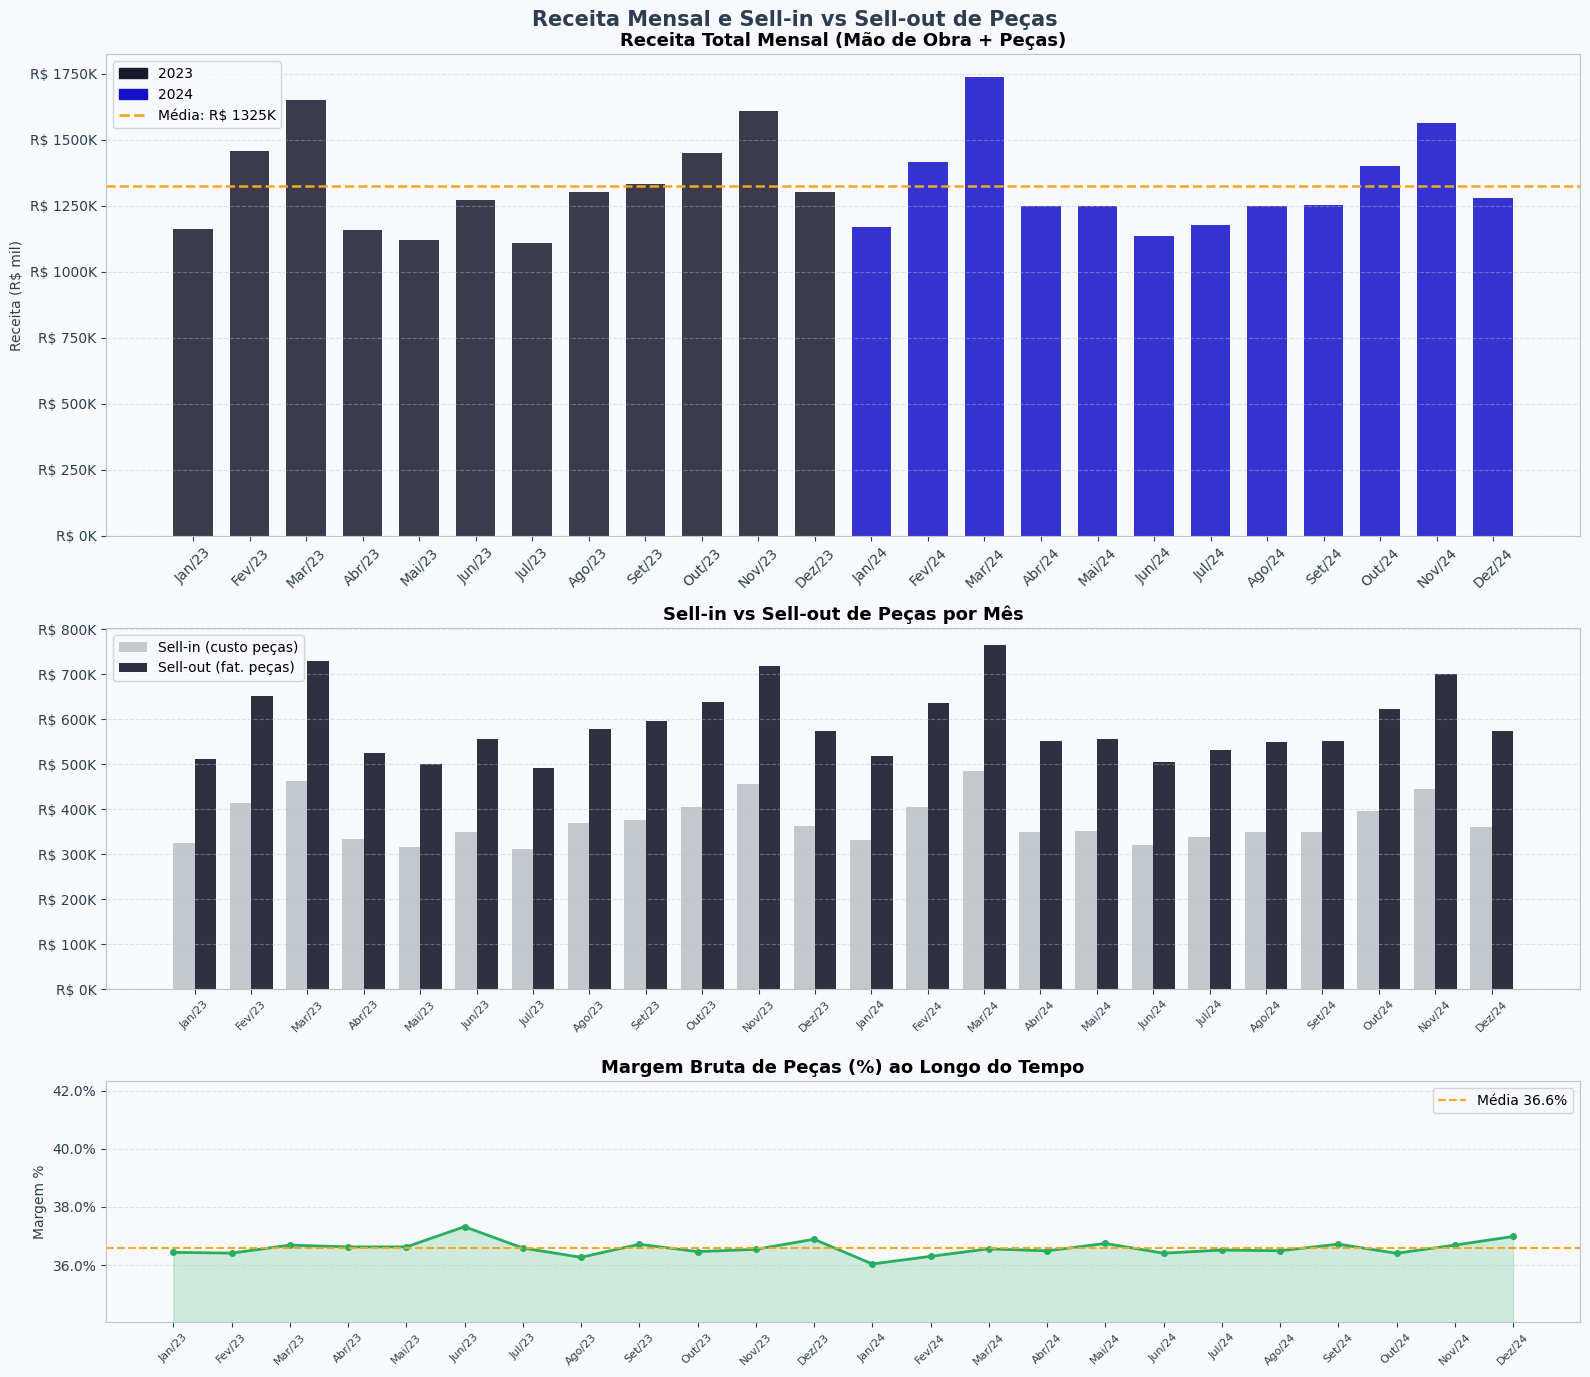

In [147]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14),
                          gridspec_kw={'height_ratios': [2, 1.5, 1]})
fig.suptitle('Receita Mensal e Sell-in vs Sell-out de Peças',
             fontsize=15, fontweight='bold', color=CORES['texto'])

#  Gráfico 1: Receita total por mês 
ax = axes[0]
cores_barra = [CORES['secundaria'] if a == 2023 else CORES['primaria']
               for a in mensal['ano']]
ax.bar(mensal['periodo'], mensal['receita'] / 1000,
       color=cores_barra, width=0.7, alpha=0.85)

media_mensal = mensal['receita'].mean() / 1000
ax.axhline(media_mensal, color=CORES['acento'], lw=1.8, ls='--',
           label=f'Média: R$ {media_mensal:.0f}K')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'R$ {x:.0f}K'))
ax.set_title('Receita Total Mensal (Mão de Obra + Peças)')
ax.set_ylabel('Receita (R$ mil)')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--')
ax.legend(loc='upper left')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=CORES['secundaria'], label='2023'),
    Patch(color=CORES['primaria'],   label='2024'),
    plt.Line2D([0], [0], color=CORES['acento'], lw=2, ls='--',
               label=f'Média: R$ {media_mensal:.0f}K'),
], loc='upper left')

# Gráfico 2: Sell-in vs Sell-out 
ax2 = axes[1]
x = np.arange(len(mensal))
w = 0.38
ax2.bar(x - w/2, mensal['sellin']  / 1000, width=w,
        label='Sell-in (custo peças)',  color=CORES['cinza'],      alpha=0.9)
ax2.bar(x + w/2, mensal['sellout'] / 1000, width=w,
        label='Sell-out (fat. peças)', color=CORES['secundaria'],  alpha=0.9)

ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'R$ {x:.0f}K'))
ax2.set_title('Sell-in vs Sell-out de Peças por Mês')
ax2.set_xticks(x)
ax2.set_xticklabels(mensal['periodo'], rotation=45, fontsize=8)
ax2.legend()
ax2.grid(axis='y', linestyle='--')

# Gráfico 3: Margem % 
ax3 = axes[2]
ax3.fill_between(range(len(mensal)), mensal['margem_pct'],
                 alpha=0.2, color=CORES['verde'])
ax3.plot(range(len(mensal)), mensal['margem_pct'],
         color=CORES['verde'], lw=2, marker='o', ms=4)
ax3.axhline(mensal['margem_pct'].mean(), color=CORES['acento'],
            ls='--', lw=1.5,
            label=f"Média {mensal['margem_pct'].mean():.1f}%")

# Y limitado à faixa real dos dados 
margem_min = mensal['margem_pct'].min()
margem_max = mensal['margem_pct'].max()
ax3.set_ylim(margem_min - 2, margem_max + 5 )  # margem de 2pp acima e abaixo

ax3.set_title('Margem Bruta de Peças (%) ao Longo do Tempo')
ax3.set_ylabel('Margem %')
ax3.set_xticks(range(len(mensal)))
ax3.set_xticklabels(mensal['periodo'], rotation=45, fontsize=8)
ax3.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'{x:.1f}%'))
ax3.legend()
ax3.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/graficos/02_receita_sellin_sellout.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Retenção e Churn de Clientes

Reter um cliente na rede custa muito menos do que conquistar um novo.

Classificamos cada cliente em 4 categorias baseadas na frequência de visitas:

| Classificação | Critério | Risco |
|---|---|---|
| Churn | Nunca visitou após cadastro | Perdido |
| Em Risco | Apenas 1 visita | Alto |
| Recorrente | 2 visitas | Médio |
| Fiel | 3 ou mais visitas | Baixo |

Em seguida fazemos uma **análise de cohort** agrupamos os clientes
pelo trimestre da primeira visita e medimos se eles voltaram.
Isso mostra se a rede está melhorando ou piorando a retenção ao longo do tempo.

In [148]:
# Frequência de visitas por cliente 
freq_cliente = (
    fa_ok
    .groupby('sk_cliente')['sk_os']
    .count()
    .reset_index()
)
freq_cliente.columns = ['sk_cliente', 'qtd_os']
freq_cliente = freq_cliente.merge(
    dcl[['sk_cliente', 'segmento_cliente', 'canal_aquisicao']],
    on='sk_cliente'
)

# Classificação
def classif_retencao(n):
    if n == 1: return 'Em Risco (1 visita)'
    if n == 2: return 'Recorrente (2 visitas)'
    return 'Fiel (3+ visitas)'

freq_cliente['retencao'] = freq_cliente['qtd_os'].map(classif_retencao)

# Resumo
print('Classificação de Retenção — Base de Clientes com visita:')
print('=' * 45)
resumo = freq_cliente['retencao'].value_counts()
for status, qtd in resumo.items():
    pct = qtd / len(freq_cliente) * 100
    print(f'  {status:<25}: {qtd:>4} clientes ({pct:.1f}%)')

Classificação de Retenção — Base de Clientes com visita:
  Fiel (3+ visitas)        : 3840 clientes (96.1%)
  Recorrente (2 visitas)   :  121 clientes (3.0%)
  Em Risco (1 visita)      :   34 clientes (0.9%)


In [149]:
#  Data da primeira visita por cliente
primeira_visita = (
    fa_ok
    .sort_values('data')
    .groupby('sk_cliente')['data']
    .min()
    .reset_index()
)
primeira_visita.columns = ['sk_cliente', 'primeira_visita']
primeira_visita['cohort'] = (
    primeira_visita['primeira_visita']
    .dt.to_period('Q')
    .astype(str)
)

# Juntar com frequência 
freq_cohort = freq_cliente.merge(primeira_visita, on='sk_cliente')

cohort_resumo = (
    freq_cohort
    .groupby('cohort')
    .agg(
        clientes        = ('sk_cliente', 'count'),
        media_visitas   = ('qtd_os', 'mean'),
        fieis           = ('qtd_os', lambda x: (x >= 3).sum())
    )
    .reset_index()
)
cohort_resumo['taxa_fidelidade'] = (
    cohort_resumo['fieis'] / cohort_resumo['clientes'] * 100
)

print('Cohort Trimestral:')
print(cohort_resumo.to_string(index=False))

Cohort Trimestral:
cohort  clientes  media_visitas  fieis  taxa_fidelidade
2023Q1      2246       7.051202   2224        99.020481
2023Q2       912       6.396930    891        97.697368
2023Q3       446       5.600897    422        94.618834
2023Q4       220       4.540909    196        89.090909
2024Q1       100       3.750000     77        77.000000
2024Q2        41       2.878049     23        56.097561
2024Q3        19       2.157895      5        26.315789
2024Q4        11       1.818182      2        18.181818


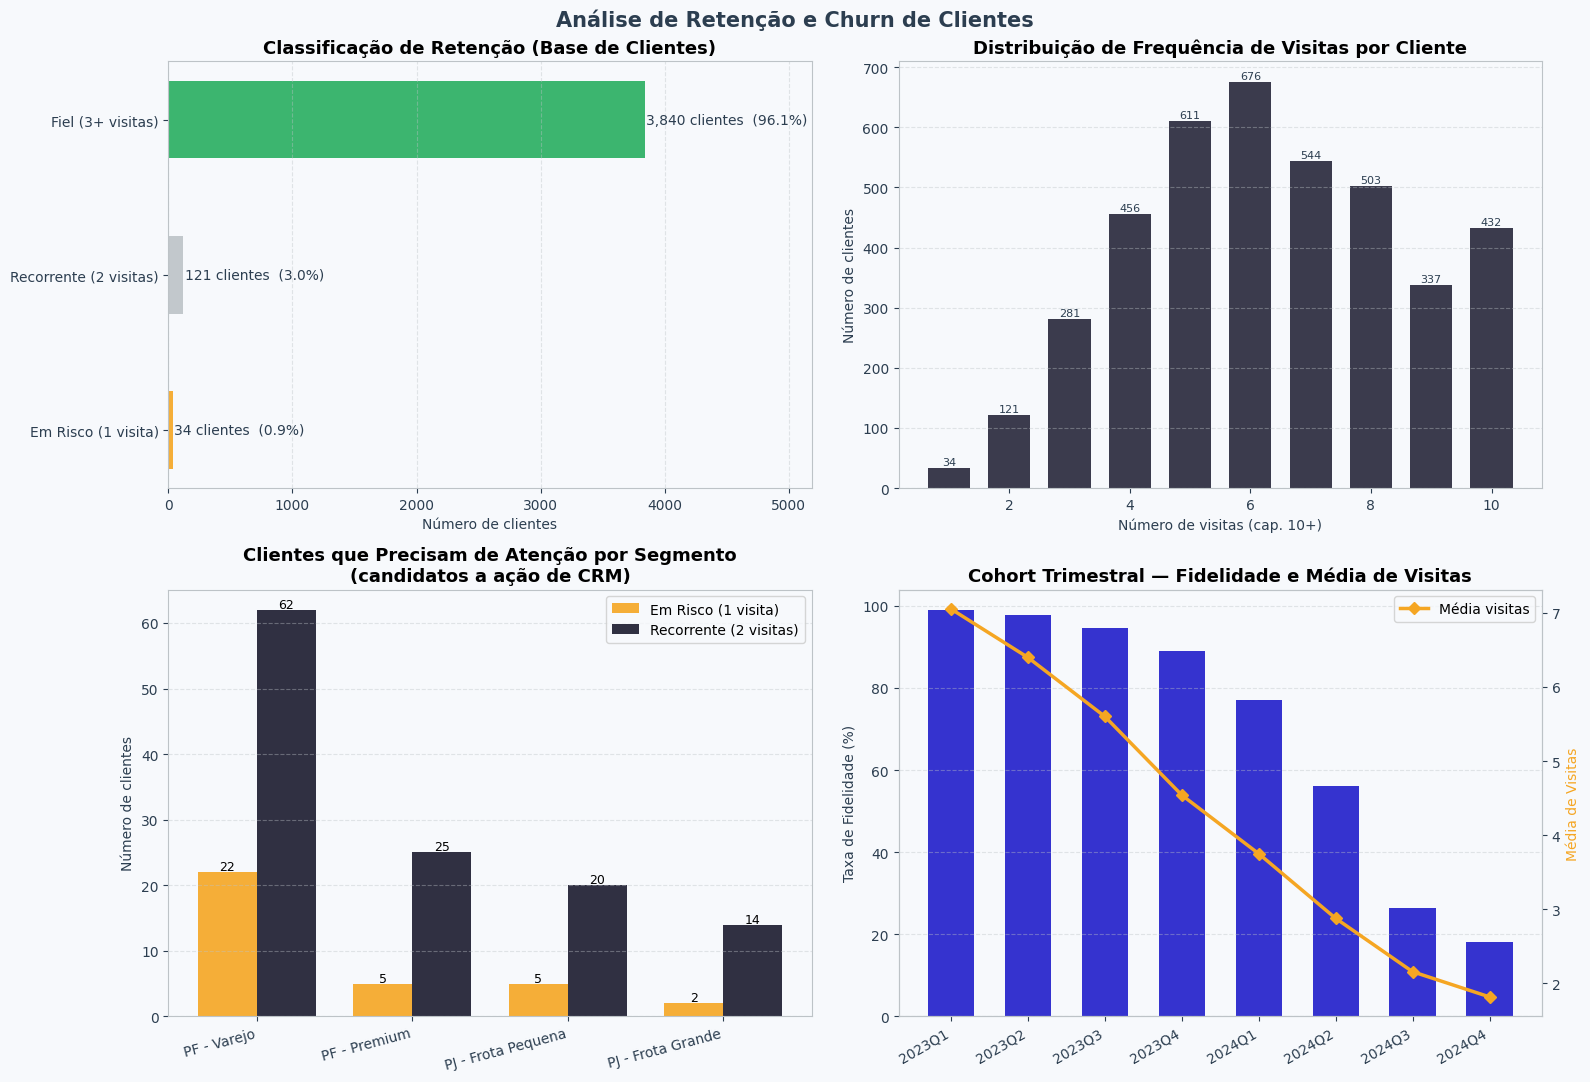

In [150]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Análise de Retenção e Churn de Clientes',
             fontsize=15, fontweight='bold', color=CORES['texto'])

#  Barras horizontais: classificação geral
ax = axes[0, 0]
order     = ['Em Risco (1 visita)', 'Recorrente (2 visitas)', 'Fiel (3+ visitas)']
ret_counts = freq_cliente['retencao'].value_counts().reindex(order).fillna(0)
cores_ret  = [CORES['acento'], CORES['cinza'], CORES['verde']]

bars = ax.barh(ret_counts.index, ret_counts.values,
               color=cores_ret, alpha=0.9, height=0.5)
for bar, (status, qtd) in zip(bars, ret_counts.items()):
    pct = qtd / len(freq_cliente) * 100
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'{int(qtd):,} clientes  ({pct:.1f}%)',
            va='center', fontsize=10, color=CORES['texto'])
ax.set_xlim(0, ret_counts.max() * 1.35)
ax.set_title('Classificação de Retenção (Base de Clientes)')
ax.set_xlabel('Número de clientes')
ax.grid(axis='x', linestyle='--')

# Histograma: distribuição de frequência 
ax2 = axes[0, 1]
freq_dist = freq_cliente['qtd_os'].clip(upper=10).value_counts().sort_index()
bars2 = ax2.bar(freq_dist.index, freq_dist.values,
                color=CORES['secundaria'], alpha=0.85, width=0.7)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, h + 5,
             f'{int(h):,}', ha='center', fontsize=8, color=CORES['texto'])
ax2.set_xlabel('Número de visitas (cap. 10+)')
ax2.set_ylabel('Número de clientes')
ax2.set_title('Distribuição de Frequência de Visitas por Cliente')
ax2.grid(axis='y', linestyle='--')

# Foco nos clientes que precisam de atenção por segmento 
ax3 = axes[1, 0]
seg_atencao = (
    freq_cliente
    .groupby('segmento_cliente')
    .apply(lambda df: pd.Series({
        'Em Risco'   : (df['qtd_os'] == 1).sum(),
        'Recorrente' : (df['qtd_os'] == 2).sum(),
    }))
    .reset_index()
)
seg_atencao = seg_atencao.sort_values('Recorrente', ascending=False).reset_index(drop=True)


x = np.arange(len(seg_atencao))
w = 0.38
ax3.bar(x - w/2, seg_atencao['Em Risco'],   width=w,
        label='Em Risco (1 visita)',       color=CORES['acento'],   alpha=0.9)
ax3.bar(x + w/2, seg_atencao['Recorrente'], width=w,
        label='Recorrente (2 visitas)',    color=CORES['secundaria'], alpha=0.9)
ax3.set_xticks(x)
ax3.set_xticklabels(seg_atencao['segmento_cliente'], rotation=15, ha='right')
ax3.set_title('Clientes que Precisam de Atenção por Segmento\n(candidatos a ação de CRM)')
ax3.set_ylabel('Número de clientes')
ax3.legend()
ax3.grid(axis='y', linestyle='--')
for bar in ax3.patches:
    h = bar.get_height()
    if h > 0:
        ax3.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                 str(int(h)), ha='center', fontsize=9)

# Cohort: taxa de fidelidade + média de visitas
ax4 = axes[1, 1]
x_cohort = np.arange(len(cohort_resumo))
ax4.bar(x_cohort, cohort_resumo['taxa_fidelidade'],
        color=CORES['primaria'], alpha=0.85, width=0.6)
ax4_twin = ax4.twinx()
ax4_twin.plot(x_cohort, cohort_resumo['media_visitas'],
              color=CORES['acento'], lw=2.5, marker='D', ms=6,
              label='Média visitas')
ax4.set_title('Cohort Trimestral — Fidelidade e Média de Visitas')
ax4.set_ylabel('Taxa de Fidelidade (%)')
ax4_twin.set_ylabel('Média de Visitas', color=CORES['acento'])
ax4.set_xticks(x_cohort)
ax4.set_xticklabels(cohort_resumo['cohort'], rotation=30, ha='right')
ax4.grid(axis='y', linestyle='--')
ax4_twin.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/graficos/03_retencao_churn.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Segmentação por Canal e Concessionária

Aqui analisamos **onde** a receita é gerada — por região, por tipo de canal
de distribuição e por concessionária individualmente.

Essa visão é essencial para o gestor de Aftersales porque responde:

- Quais regiões estão performando abaixo do potencial?
- O canal Dealer Oficial justifica o investimento em relação ao Autorizado?
- Existe alguma concessionária com alto volume mas CSAT baixo?
  (sinal de atendimento ruim que vai gerar churn)

> Essa análise de "volume vs qualidade" por dealer é exatamente o tipo
> de entregável que um Analista de Aftersales produz para o time regional.

In [151]:
# Por região 
por_regiao = (
    fa_ok
    .groupby('regiao')
    .agg(
        receita = ('vlr_total_os',       'sum'),
        qtd_os  = ('sk_os',              'count'),
        csat    = ('csat',               'mean'),
        margem  = ('margem_bruta_pecas', 'sum'),
    )
    .reset_index()
    .sort_values('receita', ascending=False)
)

# Por canal 
por_canal = (
    fa_ok
    .groupby('canal')
    .agg(
        receita = ('vlr_total_os', 'sum'),
        qtd_os  = ('sk_os',        'count'),
        csat    = ('csat',         'mean'),
    )
    .reset_index()
    .sort_values('receita', ascending=False)
)

# Por concessionária
por_conc = (
    fa_ok
    .groupby(['sk_concessionaria', 'uf', 'regiao', 'porte'])
    .agg(
        receita = ('vlr_total_os',       'sum'),
        qtd_os  = ('sk_os',              'count'),
        csat    = ('csat',               'mean'),
        margem  = ('margem_bruta_pecas', 'sum'),
    )
    .reset_index()
    .sort_values('receita', ascending=False)
)

print('Receita por Região:')
print(por_regiao[['regiao','receita','qtd_os','csat']].to_string(index=False))
print(f'\nReceita por Canal:')
print(por_canal[['canal','receita','qtd_os','csat']].to_string(index=False))

Receita por Região:
      regiao     receita  qtd_os     csat
     Sudeste 10351511.19    8243 4.216183
         Sul  6516587.69    5208 4.199501
    Nordeste  6218589.71    5108 4.212216
Centro-Oeste  4916399.23    4027 4.201887
       Norte  3796063.53    3136 4.222895

Receita por Canal:
            canal     receita  qtd_os     csat
   Dealer Oficial 15234964.13   12281 4.212605
       Multimarca 11530280.17    9257 4.193367
Dealer Autorizado  5033907.05    4184 4.242830


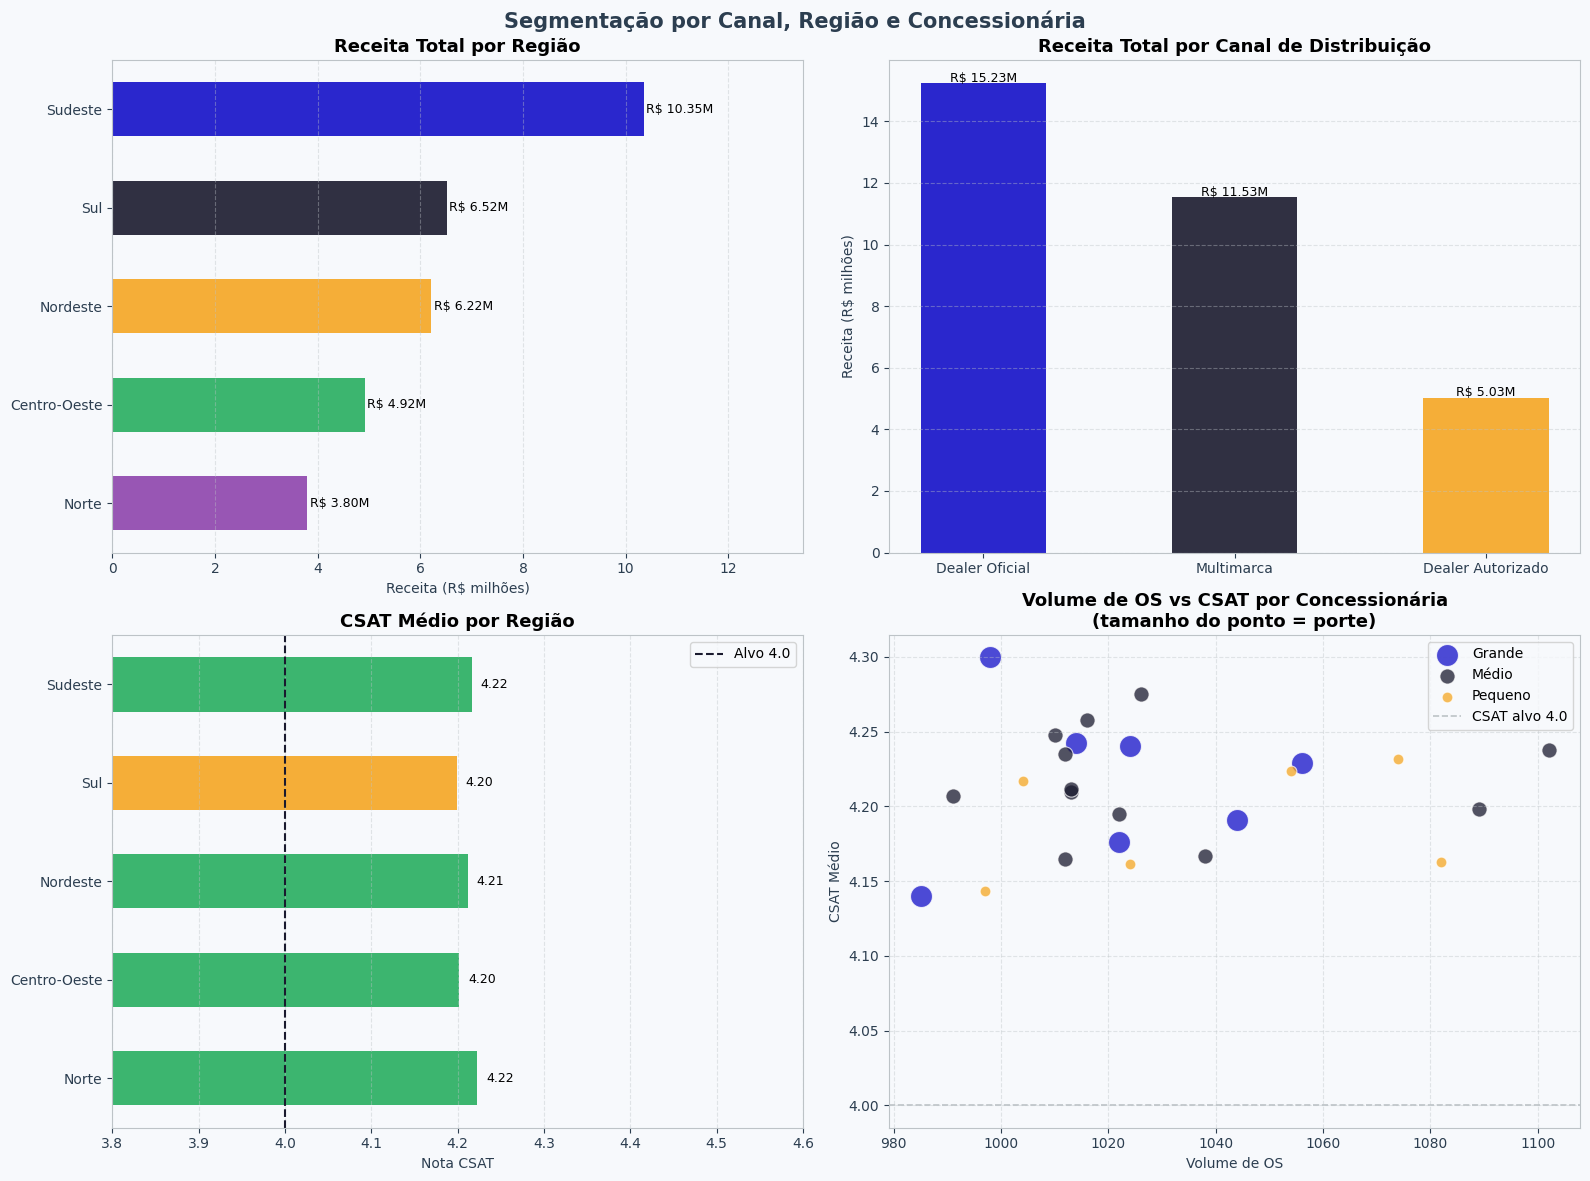

In [152]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Segmentação por Canal, Região e Concessionária',
             fontsize=15, fontweight='bold', color=CORES['texto'])

# Receita por região
ax = axes[0, 0]
bars = ax.barh(por_regiao['regiao'], por_regiao['receita'] / 1_000_000,
               color=PALETA[:len(por_regiao)], alpha=0.9, height=0.55)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.05, bar.get_y() + bar.get_height() / 2,
            f'R$ {w:.2f}M', va='center', fontsize=9)
ax.set_xlim(0, por_regiao['receita'].max() / 1_000_000 * 1.3)
ax.set_title('Receita Total por Região')
ax.set_xlabel('Receita (R$ milhões)')
ax.grid(axis='x', linestyle='--')
ax.invert_yaxis()

# Receita por canal
ax2 = axes[0, 1]
bars2 = ax2.bar(por_canal['canal'], por_canal['receita'] / 1_000_000,
                color=PALETA[:len(por_canal)], alpha=0.9, width=0.5)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.05,
             f'R$ {h:.2f}M', ha='center', fontsize=9)
ax2.set_title('Receita Total por Canal de Distribuição')
ax2.set_ylabel('Receita (R$ milhões)')
ax2.grid(axis='y', linestyle='--')

# CSAT médio por região
ax3 = axes[1, 0]
cores_csat = [CORES['verde'] if c >= 4.2 else CORES['acento'] if c >= 4.0
              else CORES['primaria'] for c in por_regiao['csat']]
bars3 = ax3.barh(por_regiao['regiao'], por_regiao['csat'],
                 color=cores_csat, alpha=0.9, height=0.55)
ax3.axvline(4.0, color=CORES['secundaria'], ls='--', lw=1.5, label='Alvo 4.0')
for bar in bars3:
    w = bar.get_width()
    ax3.text(w + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{w:.2f}', va='center', fontsize=9)
ax3.set_xlim(3.8, 4.6)
ax3.set_title('CSAT Médio por Região')
ax3.set_xlabel('Nota CSAT')
ax3.legend()
ax3.grid(axis='x', linestyle='--')
ax3.invert_yaxis()

# Scatter: volume de OS vs CSAT por concessionária
ax4 = axes[1, 1]
porte_tamanho = {'Grande': 250, 'Médio': 120, 'Pequeno': 60}
porte_cor     = {
    'Grande'  : CORES['primaria'],
    'Médio'   : CORES['secundaria'],
    'Pequeno' : CORES['acento']
}
for porte in ['Grande', 'Médio', 'Pequeno']:
    sub = por_conc[por_conc['porte'] == porte]
    ax4.scatter(sub['qtd_os'], sub['csat'],
                s=porte_tamanho[porte],
                color=porte_cor[porte],
                alpha=0.75, label=porte,
                edgecolors='white', lw=0.8)
ax4.axhline(4.0, color=CORES['cinza'], ls='--', lw=1.2, label='CSAT alvo 4.0')
ax4.set_xlabel('Volume de OS')
ax4.set_ylabel('CSAT Médio')
ax4.set_title('Volume de OS vs CSAT por Concessionária\n(tamanho do ponto = porte)')
ax4.legend()
ax4.grid(linestyle='--')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/graficos/04_segmentacao_canal.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Análise de Margem e Ticket Médio

Receita alta nem sempre significa rentabilidade alta.
Aqui analisamos **quanto sobra** de cada tipo de serviço e
**qual segmento de cliente gera mais valor por visita**.

Essa análise responde perguntas diretas de negócio:

- Qual categoria de serviço tem a melhor margem?
- Clientes PJ (frota) gastam mais por visita do que PF?
- Quais modelos de veículo geram mais receita para a rede?
- A distribuição do valor das OS tem outliers relevantes?

> Ticket médio baixo com volume alto pode ser mais lucrativo
> do que ticket alto com volume baixo — depende da margem.
> Por isso analisamos os dois juntos.

In [153]:
# Ticket médio por segmento de cliente 
ticket_seg = (
    fa_ok
    .groupby('segmento_cliente')
    .agg(
        ticket     = ('vlr_total_os',      'mean'),
        qtd_os     = ('sk_os',             'count'),
        receita    = ('vlr_total_os',      'sum'),
        sellout    = ('vlr_pecas_sellout', 'sum'),
        margem     = ('margem_bruta_pecas','sum'),
    )
    .reset_index()
    .sort_values('ticket', ascending=False)
)
ticket_seg['margem_pct'] = ticket_seg['margem'] / ticket_seg['sellout'] * 100

# Ticket médio por tipo de serviço 
ticket_serv = (
    fa_ok
    .groupby('nome_servico')
    .agg(
        ticket  = ('vlr_total_os', 'mean'),
        qtd_os  = ('sk_os',        'count'),
        csat    = ('csat',         'mean'),
    )
    .reset_index()
    .sort_values('ticket', ascending=False)
)

# Top 10 modelos por receita
por_modelo = (
    fa_ok
    .groupby('modelo')
    .agg(
        receita = ('vlr_total_os', 'sum'),
        qtd_os  = ('sk_os',        'count'),
        ticket  = ('vlr_total_os', 'mean'),
    )
    .reset_index()
    .sort_values('receita', ascending=False)
    .head(10)
)

print('Ticket Médio por Segmento:')
print(ticket_seg[['segmento_cliente','ticket','qtd_os','margem_pct']].to_string(index=False))

Ticket Médio por Segmento:
  segmento_cliente      ticket  qtd_os  margem_pct
      PF - Premium 1251.772877    5262   36.604637
 PJ - Frota Grande 1238.185941    2323   36.472595
PJ - Frota Pequena 1232.297993    5171   36.581757
       PF - Varejo 1231.204968   12966   36.591319


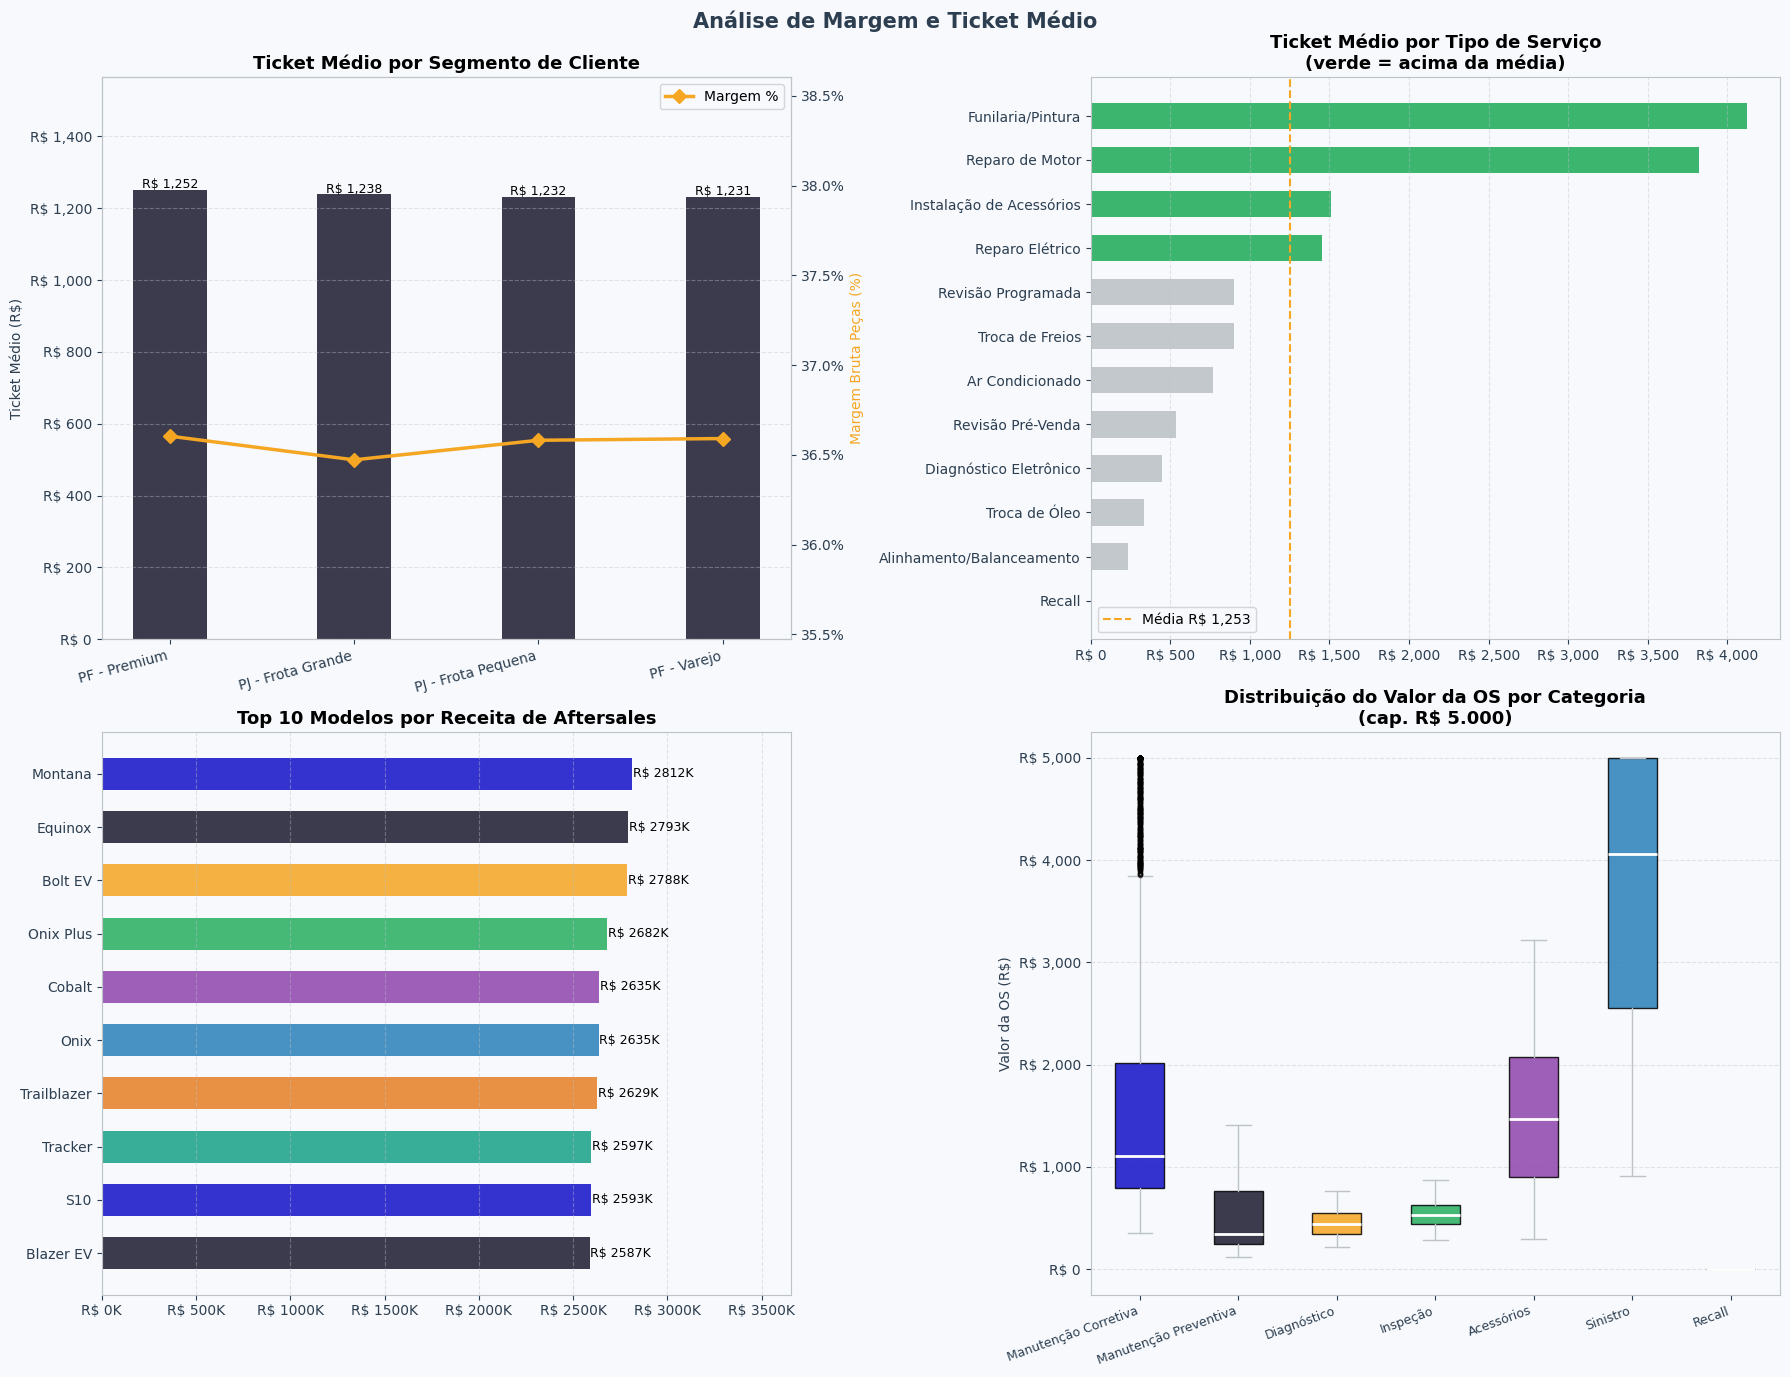

In [154]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Análise de Margem e Ticket Médio',
             fontsize=15, fontweight='bold', color=CORES['texto'])

# Ticket médio + margem % por segmento 
ax = axes[0, 0]
x = np.arange(len(ticket_seg))
w = 0.4
bars_t = ax.bar(x, ticket_seg['ticket'],
                width=w, color=CORES['secundario'] if False else CORES['secundaria'],
                alpha=0.85, label='Ticket Médio')
ax.set_xticks(x)
ax.set_xticklabels(ticket_seg['segmento_cliente'], rotation=15, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'R$ {v:,.0f}'))
ax.set_title('Ticket Médio por Segmento de Cliente')
ax.set_ylabel('Ticket Médio (R$)')
ax.grid(axis='y', linestyle='--')
for bar in bars_t:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 5,
            f'R$ {h:,.0f}', ha='center', fontsize=9)
ax.set_ylim(0, ticket_seg['ticket'].max() * 1.25)  # ← adicione essa linha
ax_twin = ax.twinx()
ax_twin.plot(x, ticket_seg['margem_pct'],
             color=CORES['acento'], lw=2.5, marker='D', ms=7,
             label='Margem %')
ax_twin.set_ylabel('Margem Bruta Peças (%)', color=CORES['acento'])
ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:.1f}%'))

margem_min = ticket_seg['margem_pct'].min()
margem_max = ticket_seg['margem_pct'].max()
ax_twin.set_ylim(margem_min - 1, margem_max + 2)

ax_twin.legend(loc='upper right')

# Ticket médio por tipo de serviço 
ax2 = axes[0, 1]
cores_serv = [CORES['verde'] if t >= ticket_serv['ticket'].mean()
              else CORES['cinza'] for t in ticket_serv['ticket']]
ax2.barh(ticket_serv['nome_servico'], ticket_serv['ticket'],
         color=cores_serv, alpha=0.9, height=0.6)
ax2.axvline(ticket_serv['ticket'].mean(), color=CORES['acento'],
            ls='--', lw=1.5,
            label=f"Média R$ {ticket_serv['ticket'].mean():,.0f}")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'R$ {v:,.0f}'))
ax2.set_title('Ticket Médio por Tipo de Serviço\n(verde = acima da média)')
ax2.legend()
ax2.invert_yaxis()
ax2.grid(axis='x', linestyle='--')

# Top 10 modelos por receita 
ax3 = axes[1, 0]
bars3 = ax3.barh(por_modelo['modelo'], por_modelo['receita'] / 1000,
                 color=PALETA[:len(por_modelo)], alpha=0.85, height=0.6)
for bar in bars3:
    w = bar.get_width()
    ax3.text(w + 5, bar.get_y() + bar.get_height() / 2,
             f'R$ {w:.0f}K', va='center', fontsize=9)
ax3.set_xlim(0, por_modelo['receita'].max() / 1000 * 1.3)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'R$ {v:.0f}K'))
ax3.set_title('Top 10 Modelos por Receita de Aftersales')
ax3.invert_yaxis()
ax3.grid(axis='x', linestyle='--')

# Boxplot: distribuição do valor da OS por categoria
ax4 = axes[1, 1]
categorias = fa_ok['categoria_servico'].unique()
data_box   = [
    fa_ok[fa_ok['categoria_servico'] == c]['vlr_total_os'].clip(upper=5000).values
    for c in categorias
]
bp = ax4.boxplot(
    data_box,
    patch_artist=True,
    notch=False,
    medianprops  = {'color': 'white', 'lw': 2},
    whiskerprops = {'color': CORES['cinza']},
    capprops     = {'color': CORES['cinza']},
    flierprops   = {'marker': 'o', 'markersize': 3, 'alpha': 0.4},
)
for patch, cor in zip(bp['boxes'], PALETA):
    patch.set_facecolor(cor)
    patch.set_alpha(0.85)
ax4.set_xticklabels(categorias, rotation=20, ha='right', fontsize=9)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'R$ {v:,.0f}'))
ax4.set_title('Distribuição do Valor da OS por Categoria\n(cap. R$ 5.000)')
ax4.set_ylabel('Valor da OS (R$)')
ax4.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/graficos/05_margem_ticket.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. CSAT e Qualidade de Atendimento

O CSAT é o termômetro da saúde da rede no longo prazo.
Um cliente insatisfeito raramente volta — e ainda faz propaganda negativa.

Aqui analisamos quatro dimensões da qualidade:

1. **Distribuição geral das notas** — a rede está polarizada ou equilibrada?
2. **CSAT por tipo de serviço** — qual serviço gera mais insatisfação?
3. **Taxa de retorno em 30 dias por complexidade** — serviços complexos
   geram mais retrabalho?
4. **Tempo de atendimento vs nota CSAT** — demorar mais impacta a satisfação?

> Um analista que cruza CSAT com tempo de atendimento e tipo de serviço
> entrega insights acionáveis — não só um número médio.

In [155]:
# CSAT por tipo de serviço 
csat_serv = (
    fa_ok
    .groupby('nome_servico')['csat']
    .agg(['mean', 'count'])
    .reset_index()
    .sort_values('mean', ascending=False)
)
csat_serv.columns = ['nome_servico', 'csat_medio', 'qtd_os']

# Taxa de retorno em 30 dias por complexidade 
ret_compl = (
    fa_ok
    .groupby('complexidade')['retornou_30d']
    .mean()
    .reset_index()
    .sort_values('retornou_30d', ascending=False)
)
ret_compl['retornou_30d'] = ret_compl['retornou_30d'] * 100

# Faixa de tempo de atendimento 

fa_ok['faixa_tempo'] = pd.cut(
    fa_ok['tempo_atendimento_h'],
    bins=[0, 2, 4, 6, 8],
    labels=['1-2h', '3-4h', '5-6h', '7-8h']
)

print('CSAT por Serviço:')
print(csat_serv.to_string(index=False))
print(f'\nTaxa de Retorno em 30d por Complexidade:')
print(ret_compl.to_string(index=False))

CSAT por Serviço:
             nome_servico  csat_medio  qtd_os
   Diagnóstico Eletrônico    4.232004    2181
        Funilaria/Pintura    4.230955    2074
Alinhamento/Balanceamento    4.229018    2109
        Revisão Pré-Venda    4.226642    2162
          Ar Condicionado    4.221395    2150
       Revisão Programada    4.220447    2191
            Troca de Óleo    4.218343    2148
 Instalação de Acessórios    4.197792    2083
          Reparo de Motor    4.196266    2089
          Reparo Elétrico    4.187299    2173
          Troca de Freios    4.183898    2186
                   Recall    4.183824    2176

Taxa de Retorno em 30d por Complexidade:
complexidade  retornou_30d
        Alto      8.143939
       Baixo      7.639533
       Médio      7.372093


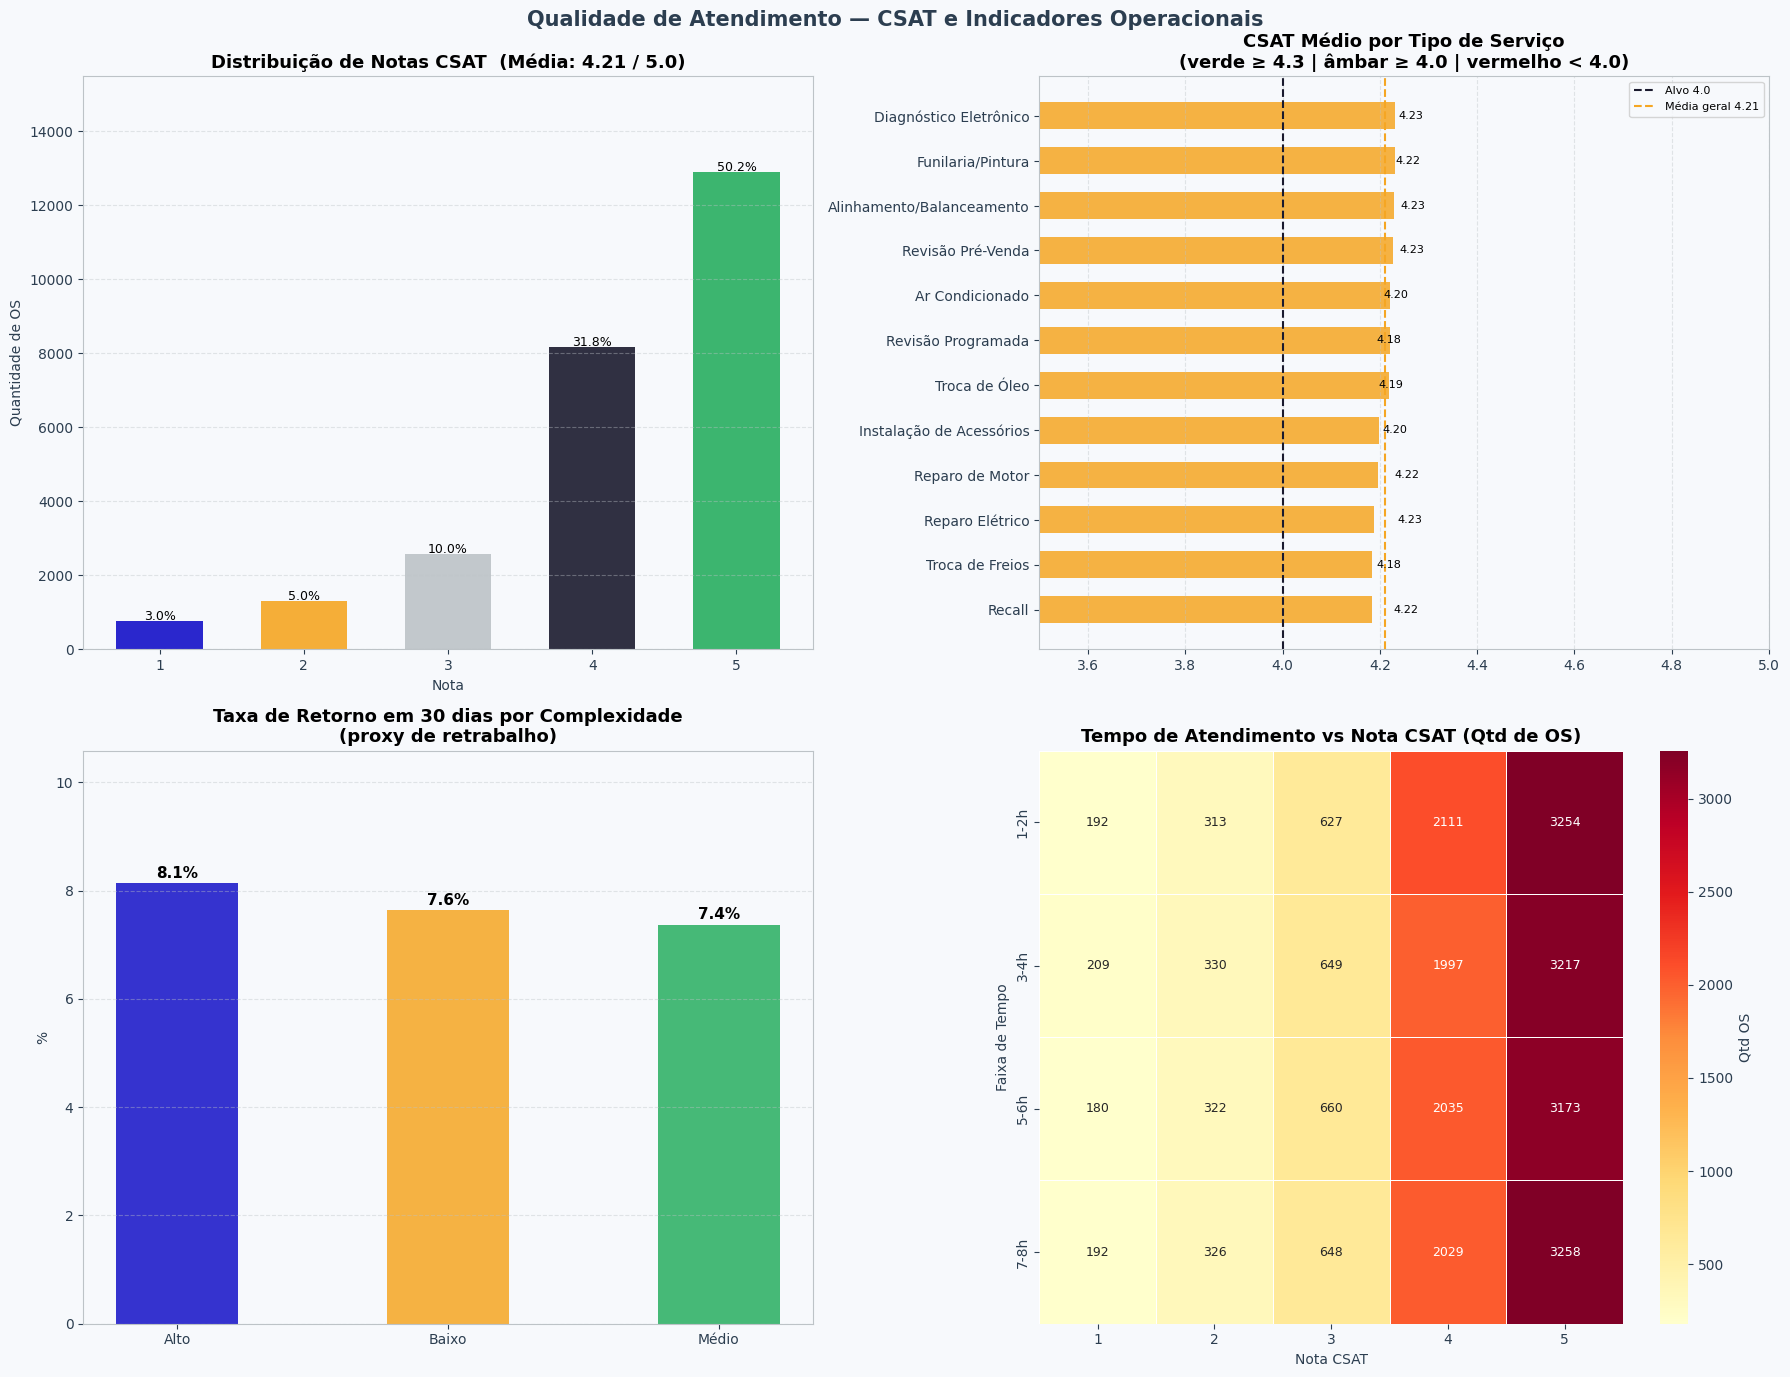

In [156]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Qualidade de Atendimento — CSAT e Indicadores Operacionais',
             fontsize=15, fontweight='bold', color=CORES['texto'])

# Distribuição geral de notas CSAT 
ax = axes[0, 0]
csat_dist  = fa_ok['csat'].value_counts().sort_index()
cores_csat = [CORES['primaria'], CORES['acento'], CORES['cinza'],
              CORES['secundaria'], CORES['verde']]
bars = ax.bar(csat_dist.index.astype(str), csat_dist.values,
              color=cores_csat, alpha=0.9, width=0.6)
for bar in bars:
    h   = bar.get_height()
    pct = h / len(fa_ok) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, h + 30,
            f'{pct:.1f}%', ha='center', fontsize=9)
ax.set_title(f'Distribuição de Notas CSAT  (Média: {fa_ok["csat"].mean():.2f} / 5.0)')
ax.set_xlabel('Nota')
ax.set_ylabel('Quantidade de OS')
ax.set_ylim(0, csat_dist.max() * 1.2)
ax.grid(axis='y', linestyle='--')

# CSAT médio por tipo de serviço 
ax2 = axes[0, 1]
cores_serv = [
    CORES['verde']    if m >= 4.3 else
    CORES['acento']   if m >= 4.0 else
    CORES['primaria']
    for m in csat_serv['csat_medio']
]
ax2.barh(csat_serv['nome_servico'], csat_serv['csat_medio'],
         color=cores_serv, alpha=0.85, height=0.6)
ax2.axvline(4.0, color=CORES['secundaria'], ls='--', lw=1.5, label='Alvo 4.0')
ax2.axvline(fa_ok['csat'].mean(), color=CORES['acento'], ls='--', lw=1.5,
            label=f'Média geral {fa_ok["csat"].mean():.2f}')
for i, row in csat_serv.iterrows():
    ax2.text(row['csat_medio'] + 0.01, i,
             f'{row["csat_medio"]:.2f}', va='center', fontsize=8)
ax2.set_xlim(3.5, 5.0)
ax2.set_title('CSAT Médio por Tipo de Serviço\n(verde ≥ 4.3 | âmbar ≥ 4.0 | vermelho < 4.0)')
ax2.legend(fontsize=8)
ax2.invert_yaxis()
ax2.grid(axis='x', linestyle='--')

# Taxa de retorno em 30 dias por complexidade 
ax3 = axes[1, 0]
cores_compl = [CORES['primaria'], CORES['acento'], CORES['verde']]
bars3 = ax3.bar(ret_compl['complexidade'], ret_compl['retornou_30d'],
                color=cores_compl[:len(ret_compl)], alpha=0.85, width=0.45)
for bar in bars3:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width() / 2, h + 0.1,
             f'{h:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax3.set_title('Taxa de Retorno em 30 dias por Complexidade\n(proxy de retrabalho)')
ax3.set_ylabel('%')
ax3.set_ylim(0, ret_compl['retornou_30d'].max() * 1.3)
ax3.grid(axis='y', linestyle='--')

# Heatmap: tempo de atendimento vs nota CSAT 
ax4 = axes[1, 1]
heat_data = (
    fa_ok
    .groupby(['faixa_tempo', 'csat'])['sk_os']
    .count()
    .reset_index()
    .pivot(index='faixa_tempo', columns='csat', values='sk_os')
    .fillna(0)
)
sns.heatmap(
    heat_data, ax=ax4,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Qtd OS'},
    annot_kws={'fontsize': 9}
)
ax4.set_title('Tempo de Atendimento vs Nota CSAT (Qtd de OS)')
ax4.set_xlabel('Nota CSAT')
ax4.set_ylabel('Faixa de Tempo')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/graficos/06_csat_qualidade.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Funil de Pós-Venda e Recompra

O funil de pós-venda mostra a jornada completa do cliente —
desde o cadastro até a recompra de um novo veículo.

Essa é a análise que fecha o ciclo do Aftersales:
um cliente bem atendido na oficina tem muito mais chance de
comprar o próximo carro na mesma rede.

As etapas do funil são:

| Etapa | Descrição |
|---|---|
| Base de Clientes | Total de clientes cadastrados |
| Pelo menos 1 visita | Clientes que usaram a rede ao menos uma vez |
| 2+ visitas | Começaram a criar hábito |
| 3+ visitas (Fiel) | Clientes consolidados na rede |
| Recompra | Compraram um novo veículo em 2024 |

> A taxa de conversão entre etapas é o número que o gestor
> usa para definir onde concentrar o esforço de CRM.

In [157]:
# Etapas do funil 
total_clientes = len(dcl)
com_visita     = fa_ok['sk_cliente'].nunique()
recorrentes    = freq_cliente[freq_cliente['qtd_os'] >= 2]['sk_cliente'].nunique()
fieis          = freq_cliente[freq_cliente['qtd_os'] >= 3]['sk_cliente'].nunique()
recompradores  = len(fr)

funil = pd.DataFrame({
    'etapa' : [
        'Base de Clientes',
        'Pelo menos 1 visita',
        '2+ visitas',
        '3+ visitas (Fiel)',
        'Recompra'
    ],
    'qtd' : [total_clientes, com_visita, recorrentes, fieis, recompradores],
})

funil['pct_base']  = funil['qtd'] / total_clientes * 100
funil['pct_etapa'] = [100.0] + [
    funil['qtd'][i] / funil['qtd'][i - 1] * 100
    for i in range(1, len(funil))
]

print('Funil de Pós-Venda:')
print('=' * 60)
for _, row in funil.iterrows():
    print(f"  {row['etapa']:<25}: {row['qtd']:>5,} "
          f"({row['pct_base']:.1f}% da base | "
          f"{row['pct_etapa']:.1f}% da etapa anterior)")

Funil de Pós-Venda:
  Base de Clientes         : 4,000 (100.0% da base | 100.0% da etapa anterior)
  Pelo menos 1 visita      : 3,995 (99.9% da base | 99.9% da etapa anterior)
  2+ visitas               : 3,961 (99.0% da base | 99.1% da etapa anterior)
  3+ visitas (Fiel)        : 3,840 (96.0% da base | 96.9% da etapa anterior)
  Recompra                 :   716 (17.9% da base | 18.6% da etapa anterior)


In [158]:
#  Enriquecer fato_recompra 
fr_enriquecido = (
    fr
    .merge(dt[['sk_tempo', 'ano', 'trimestre']], on='sk_tempo')
    .merge(dv[['sk_veiculo', 'modelo', 'segmento']],
           left_on='sk_veiculo_novo', right_on='sk_veiculo')
    .merge(dcl[['sk_cliente', 'segmento_cliente']], on='sk_cliente')
)

# Recompras por canal de venda
canal_recomp = (
    fr_enriquecido
    .groupby('canal_venda')['sk_recompra']
    .count()
    .reset_index()
    .sort_values('sk_recompra', ascending=False)
)

# Recompras por segmento de cliente
seg_recomp = (
    fr_enriquecido
    .groupby('segmento_cliente')['sk_recompra']
    .count()
    .reset_index()
    .sort_values('sk_recompra', ascending=False)
)

# Ticket médio de recompra por segmento
ticket_recomp = (
    fr_enriquecido
    .groupby('segmento_cliente')['vlr_veiculo']
    .mean()
    .reset_index()
    .sort_values('vlr_veiculo', ascending=False)
)

print(f'Total de recompras     : {len(fr_enriquecido):,}')
print(f'Ticket médio recompra  : R$ {fr_enriquecido["vlr_veiculo"].mean():,.0f}')
print(f'% financiados          : {fr_enriquecido["financiado"].mean()*100:.1f}%')

Total de recompras     : 716
Ticket médio recompra  : R$ 207,350
% financiados          : 65.2%


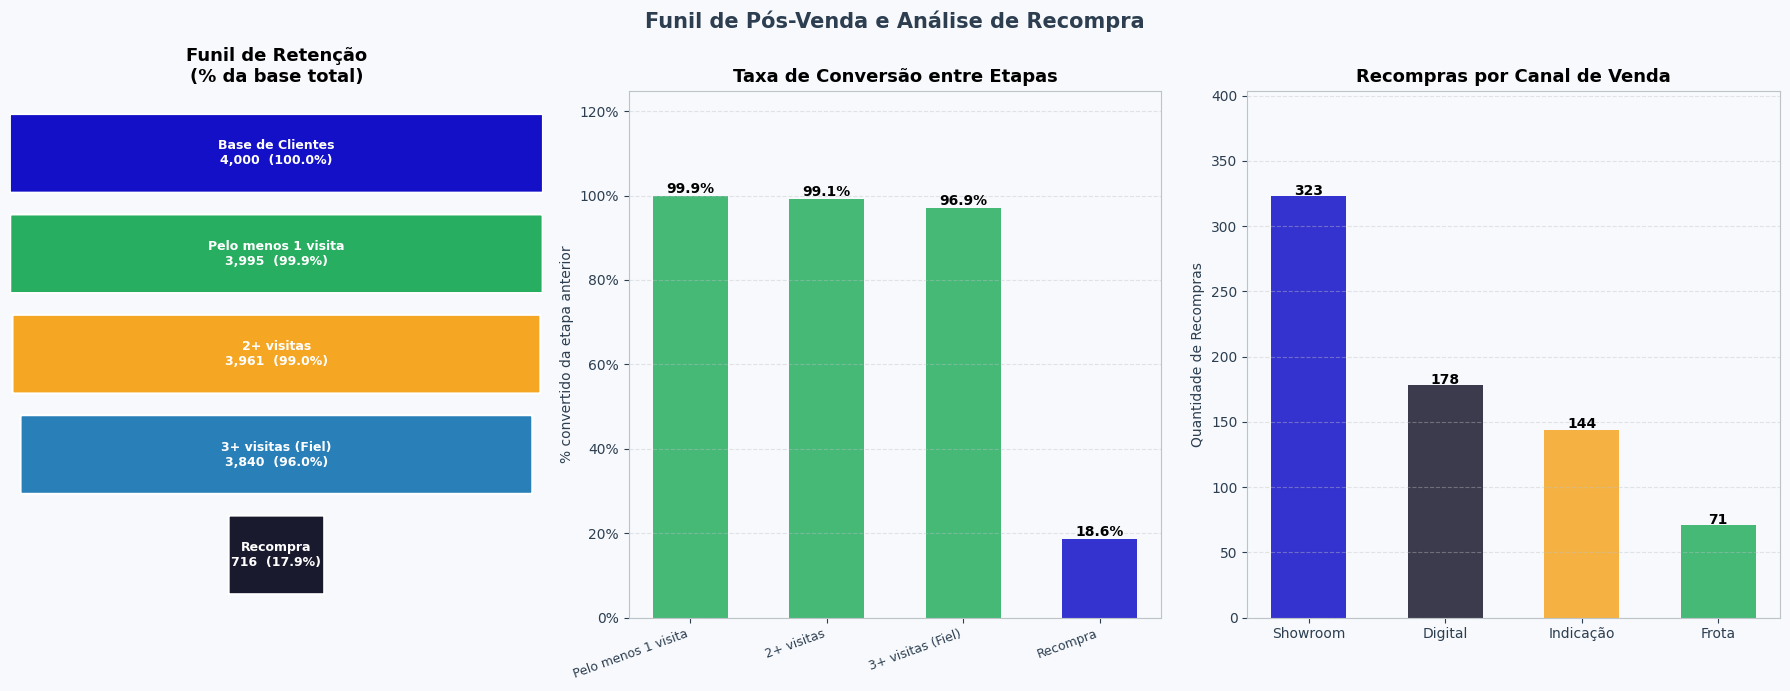

In [159]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Funil de Pós-Venda e Análise de Recompra',
             fontsize=15, fontweight='bold', color=CORES['texto'])

# Funil visual 
ax = axes[0]
cores_funil = [
    CORES['secundaria'], '#2980B9', CORES['acento'],
    CORES['verde'], CORES['primaria']
]

funil_plot = funil.iloc[::-1].reset_index(drop=True) 

for i, (row, cor) in enumerate(zip(funil_plot.itertuples(), cores_funil)):
    largura = row.pct_base
    margem  = (100 - largura) / 2
    from matplotlib.patches import FancyBboxPatch
    ax.add_patch(FancyBboxPatch(
        (margem, i * 1.2), largura, 0.9,
        boxstyle='round,pad=0.02',
        facecolor=cor, edgecolor='white', lw=1.5
    ))
    ax.text(50, i * 1.2 + 0.45,
            f'{row.etapa}\n{row.qtd:,}  ({row.pct_base:.1f}%)',
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
ax.set_xlim(0, 100)
ax.set_ylim(-0.3, len(funil) * 1.2)
ax.axis('off')
ax.set_title('Funil de Retenção\n(% da base total)')

# Conversão entre etapas 
ax2 = axes[1]
etapas_trans = funil['etapa'].values[1:]
taxas        = funil['pct_etapa'].values[1:]
cores_conv   = [
    CORES['verde']    if t >= 50 else
    CORES['acento']   if t >= 25 else
    CORES['primaria']
    for t in taxas
]
bars2 = ax2.bar(range(len(etapas_trans)), taxas,
                color=cores_conv, alpha=0.85, width=0.55)
for bar, t in zip(bars2, taxas):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.8,
             f'{t:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_xticks(range(len(etapas_trans)))
ax2.set_xticklabels(etapas_trans, rotation=20, ha='right', fontsize=9)
ax2.set_title('Taxa de Conversão entre Etapas')
ax2.set_ylabel('% convertido da etapa anterior')
ax2.set_ylim(0, max(taxas) * 1.25)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, p: f'{v:.0f}%'))
ax2.grid(axis='y', linestyle='--')

# Recompras por canal e segmento 
ax3 = axes[2]
x = np.arange(len(canal_recomp))
bars3 = ax3.bar(canal_recomp['canal_venda'], canal_recomp['sk_recompra'],
                color=PALETA[:len(canal_recomp)], alpha=0.85, width=0.55)
for bar in bars3:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width() / 2, h + 1,
             str(int(h)), ha='center', fontsize=10, fontweight='bold')
ax3.set_title('Recompras por Canal de Venda')
ax3.set_ylabel('Quantidade de Recompras')
ax3.set_ylim(0, canal_recomp['sk_recompra'].max() * 1.25)
ax3.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/graficos/07_funil_recompra.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Conclusões e Insights Acionáveis

In [160]:
print('=' * 62)
print('  INSIGHTS ACIONÁVEIS — AFTERSALES 2023–2024')
print('=' * 62)

# Receita e margem 
crescimento = (
    fa_ok[fa_ok['ano'] == 2024]['vlr_total_os'].sum() /
    fa_ok[fa_ok['ano'] == 2023]['vlr_total_os'].sum() - 1
) * 100

margem_media = (
    fa_ok['margem_bruta_pecas'].sum() /
    fa_ok['vlr_pecas_sellout'].sum() * 100
)

print(f"""
 RECEITA E MARGEM
   Crescimento 2023 → 2024 : {crescimento:+.1f}%
   Margem bruta de peças   : {margem_media:.1f}%
   Pico de receita         : {mensal.loc[mensal['receita'].idxmax(), 'periodo']}
   Vale de receita         : {mensal.loc[mensal['receita'].idxmin(), 'periodo']}
""")

#  Retenção 
clientes_risco = freq_cliente[freq_cliente['qtd_os'] == 1]
seg_mais_risco = clientes_risco['segmento_cliente'].value_counts().index[0]

print(f"""RETENÇÃO E CHURN
   Clientes fiéis (3+ visitas) : {fieis:,}  ({fieis/com_visita*100:.1f}% dos que visitaram)
   Clientes em risco (1 visita): {len(clientes_risco):,}  — candidatos a CRM
   Segmento com mais em risco  : {seg_mais_risco}
   Taxa de recompra            : {taxa_recompra:.1f}% da base total
""")

#  Canal e região
top_regiao = por_regiao.iloc[0]
top_canal  = por_canal.iloc[0]

print(f"""CANAL E REGIÃO
   Região líder    : {top_regiao['regiao']}  (R$ {top_regiao['receita']/1_000_000:.2f}M)
   Canal dominante : {top_canal['canal']}  ({top_canal['receita']/receita_total*100:.1f}% da receita)
""")

# Qualidade 
melhor_serv = csat_serv.iloc[0]
pior_serv   = csat_serv.iloc[-1]

print(f"""QUALIDADE DE ATENDIMENTO
   CSAT médio geral        : {fa_ok['csat'].mean():.2f} / 5.0
   Serviço melhor avaliado : {melhor_serv['nome_servico']}  ({melhor_serv['csat_medio']:.2f})
   Serviço pior avaliado   : {pior_serv['nome_servico']}  ({pior_serv['csat_medio']:.2f})
   Taxa de retrabalho      : {fa_ok['retornou_30d'].mean()*100:.1f}%  (retorno em 30 dias)
""")

# Recomendações 
print(f"""RECOMENDAÇÕES
   1. Acionar campanha de CRM para os {len(clientes_risco):,} clientes
      com apenas 1 visita — especialmente no segmento {seg_mais_risco}

   2. Investigar queda de receita em {mensal.loc[mensal['receita'].idxmin(), 'periodo']}
      — avaliar se foi sazonalidade ou problema operacional

   3. Priorizar plano de qualidade para o serviço
      "{pior_serv['nome_servico']}" — menor CSAT da rede ({pior_serv['csat_medio']:.2f})

   4. Replicar práticas das concessionárias com alto CSAT
      e volume para as que estão abaixo da média

   5. Investigar a baixa conversão de Fiel → Recompra ({taxa_recompra:.1f}%)
      — pode indicar gap na abordagem comercial pós-revisão
""")
print('=' * 62)

  INSIGHTS ACIONÁVEIS — AFTERSALES 2023–2024

 RECEITA E MARGEM
   Crescimento 2023 → 2024 : -0.3%
   Margem bruta de peças   : 36.6%
   Pico de receita         : Mar/24
   Vale de receita         : Jul/23

RETENÇÃO E CHURN
   Clientes fiéis (3+ visitas) : 3,840  (96.1% dos que visitaram)
   Clientes em risco (1 visita): 34  — candidatos a CRM
   Segmento com mais em risco  : PF - Varejo
   Taxa de recompra            : 17.9% da base total

CANAL E REGIÃO
   Região líder    : Sudeste  (R$ 10.35M)
   Canal dominante : Dealer Oficial  (47.9% da receita)

QUALIDADE DE ATENDIMENTO
   CSAT médio geral        : 4.21 / 5.0
   Serviço melhor avaliado : Diagnóstico Eletrônico  (4.23)
   Serviço pior avaliado   : Recall  (4.18)
   Taxa de retrabalho      : 7.7%  (retorno em 30 dias)

RECOMENDAÇÕES
   1. Acionar campanha de CRM para os 34 clientes
      com apenas 1 visita — especialmente no segmento PF - Varejo

   2. Investigar queda de receita em Jul/23
      — avaliar se foi sazonalidade ou p

---
## 11. Exportação Final e Estrutura do Projeto

In [161]:
import os

print('=' * 55)
print('  CHECKLIST DE ARQUIVOS DO PROJETO')
print('=' * 55)

estrutura = {
    DATA_DIR: [
        'fato_atendimento.csv', 'fato_recompra.csv',
        'dim_cliente.csv', 'dim_concessionaria.csv',
        'dim_veiculo.csv', 'dim_servico.csv', 'dim_tempo.csv'
    ],
    f'{OUTPUT_DIR}\\graficos': [
        '01_sumario_executivo.png',
        '02_receita_sellin_sellout.png',
        '03_retencao_churn.png',
        '04_segmentacao_canal.png',
        '05_margem_ticket.png',
        '06_csat_qualidade.png',
        '07_funil_recompra.png',
    ],
}

todos_ok = True
for pasta, arquivos in estrutura.items():
    print(f'\n  📁 {pasta}')
    for arquivo in arquivos:
        caminho = os.path.join(pasta, arquivo)
        existe  = os.path.exists(caminho)
        status  = '✅' if existe else '❌ NÃO ENCONTRADO'
        print(f'     {status}  {arquivo}')
        if not existe:
            todos_ok = False

print('\n' + '=' * 55)
if todos_ok:
    print('  ✅ Todos os arquivos encontrados!')
else:
    print('  ⚠️  Arquivos faltando — verifique os caminhos acima.')
print('=' * 55)

  CHECKLIST DE ARQUIVOS DO PROJETO

  📁 C:\Users\fabio\analytics\project\projeto_2_dashboard_pos_venda\raw
     ✅  fato_atendimento.csv
     ✅  fato_recompra.csv
     ✅  dim_cliente.csv
     ✅  dim_concessionaria.csv
     ✅  dim_veiculo.csv
     ✅  dim_servico.csv
     ✅  dim_tempo.csv

  📁 C:\Users\fabio\analytics\project\projeto_2_dashboard_pos_venda\output\graficos
     ✅  01_sumario_executivo.png
     ✅  02_receita_sellin_sellout.png
     ✅  03_retencao_churn.png
     ✅  04_segmentacao_canal.png
     ✅  05_margem_ticket.png
     ✅  06_csat_qualidade.png
     ✅  07_funil_recompra.png

  ✅ Todos os arquivos encontrados!
